<a href="https://colab.research.google.com/github/mahsawye/robust-visual-segmentation/blob/main/notebooks/01_coco_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Imports


In [ ]:
# Install required packages if they are not already installed.
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/90.0 kB 9.7 MB/s eta 0:00:00


In [ ]:
import json
import requests

from io import BytesIO
from PIL import Image

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


# 2. Configuration

In [ ]:
annotation_path = "/content/annotations/instances_val2017.json"

device = 0
target_category = "dog"
prototype_subset_size = 20

In [ ]:
!wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip -q annotations_trainval2017.zip -d /content/

# 3. Load COCO Dataset

In [ ]:
with open(annotation_path, "r") as f:
    coco_data = json.load(f)

categories = coco_data["categories"]

In [ ]:
# sanity check
print(coco_data.keys())
print("Number of images:", len(coco_data["images"]))
print("Number of annotations:", len(coco_data["annotations"]))
print("Number of categories:", len(coco_data["categories"]))

dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])
Number of images: 5000
Number of annotations: 36781
Number of categories: 80


# 4. Helper Functions

In [ ]:
# Convert a COCO bounding box from [x, y, width, height]
# to [x1, y1, x2, y2] format.
def coco_to_xyxy(coco_box):
    x, y, width, height = coco_box

    x1 = x
    y1 = y
    x2 = x + width
    y2 = y + height

    box_xyxy = [x1, y1, x2, y2]

    return [round(value, 2) for value in box_xyxy]

In [ ]:
# Find the category name corresponding to a COCO category ID.
def get_category_name(category_id, categories):
    for category in categories:
        if category["id"] == category_id:
            return category["name"]

    return None

In [ ]:
# Calculate Intersection over Union (IoU) between two bounding boxes.
# The boxes must be in [x1, y1, x2, y2] format.
def calculate_iou(box_a, box_b):
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])

    x_left = max(box_a[0], box_b[0])
    y_top = max(box_a[1], box_b[1])
    x_right = min(box_a[2], box_b[2])
    y_bottom = min(box_a[3], box_b[3])

    intersection_width = max(0, x_right - x_left)
    intersection_height = max(0, y_bottom - y_top)

    intersection_area = intersection_width * intersection_height

    union_area = area_a + area_b - intersection_area

    iou = intersection_area / union_area

    return iou

In [ ]:
# Find image metadata for a COCO image ID.
def get_image_info(image_id):
    for image in coco_data['images']:
        if image['id'] == image_id:
            return image

    raise ValueError(f'Image ID {image_id} was not found.')

In [ ]:
# Return all annotations belonging to one image.
def get_image_annotations(image_id):
    image_annotations = []

    for annotation in coco_data["annotations"]:
        if annotation["image_id"] == image_id:
            image_annotations.append(annotation)

    return image_annotations

In [ ]:
# sanity check
image_annotations = get_image_annotations(289343)

print("Number of annotations:", len(image_annotations))

for annotation in image_annotations:
    print(
        "Category:",
        get_category_name(annotation["category_id"], categories),
        "| Box:",
        annotation["bbox"]
    )

Number of annotations: 4
Category: dog | Box: [473.07, 395.93, 38.65, 28.67]
Category: person | Box: [204.01, 235.08, 60.84, 177.36]
Category: bench | Box: [0.43, 499.79, 339.79, 106.45]
Category: bicycle | Box: [204.42, 304.1, 52.51, 152.76]


In [ ]:
def load_coco_image(image_id):
    # Find the image information for the given image ID.
    image_info = get_image_info(image_id)

    # Build the COCO image URL.
    file_name = image_info["file_name"]
    image_url = f"http://images.cocodataset.org/val2017/{file_name}"

    # Download and load the image.
    response = requests.get(image_url)
    response.raise_for_status()
    image = Image.open(BytesIO(response.content)).convert("RGB")

    return image

# 5. Visualization

In [ ]:
# Draw all bounding boxes and category labels on the image.
def draw_annotations(ax, image_annotations):
    for annotation in image_annotations:
        box_xyxy = coco_to_xyxy(annotation["bbox"])

        category_name = get_category_name(
            annotation["category_id"],
            categories
        )

        x1, y1, x2, y2 = box_xyxy

        rect = Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rect)

        ax.text(
            x1,
            y1,
            category_name,
            fontsize=10,
            verticalalignment="bottom"
        )

    ax.axis("off")

In [ ]:
# Display a COCO image together with its ground-truth annotations.
def visualize_image_annotations(image_id):
    image = load_coco_image(image_id)
    image_annotations = get_image_annotations(image_id)

    fig, ax = plt.subplots(figsize=(6, 7))
    ax.imshow(image)
    draw_annotations(ax, image_annotations)
    plt.show()

# 6. Sanity Checks

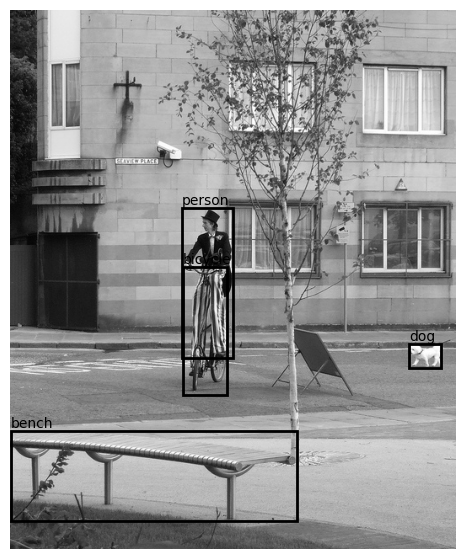

In [ ]:
# Visualize one COCO image with its ground-truth annotations.
sanity_check_image_id = 289343
visualize_image_annotations(sanity_check_image_id)

# 7. Select Dog Annotations


In [ ]:
dog_annotations = []

for annotation in coco_data['annotations']:
    category_name = get_category_name(
        annotation['category_id'],
        categories
    )

    if category_name == target_category:
        dog_annotations.append(annotation)

unique_dog_image_ids = {
    annotation['image_id']
    for annotation in dog_annotations
}

print('Number of dog annotations:', len(dog_annotations))
print('Number of images containing dogs:', len(unique_dog_image_ids))

Number of dog annotations: 218
Number of images containing dogs: 177


# 8. Select Prototype Experimental Subset

In [ ]:
# Select a small subset for the initial pipeline prototype.
experiment_annotations = dog_annotations[:prototype_subset_size]

experiment_image_ids = {
    annotation['image_id']
    for annotation in experiment_annotations
}

print('Prototype annotations:', len(experiment_annotations))
print('Prototype images:', len(experiment_image_ids))

Prototype annotations: 20
Prototype images: 20


This subset is used only to validate the experimental pipeline. It is not the final evaluation subset.



# 9. Object Detection

In [ ]:
model = YOLO("yolo26n.pt")

In [ ]:
# Extract detections classified as dog.
def get_dog_detections(result):
    dog_detections = []

    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = result.names[class_id]

        if class_name == "dog":
            dog_detections.append({
                "box": box.xyxy[0].tolist(),
                "confidence": float(box.conf[0])
            })

    return dog_detections

In [ ]:
# Run object detection and return dog detections.
def detect_dogs(image):
    results = model.predict(
        source=image,
        device=device,
        verbose=False
    )

    result = results[0]

    # Get dog detections.
    dog_detections = get_dog_detections(result)

    return dog_detections

In [ ]:
# Select the detected dog box with the highest IoU against the ground-truth box.
# This is used only for evaluation matching in the prototype.
def select_best_detection(detections, ground_truth_box):
    if not detections:
        return None

    return max(
        detections,
        key=lambda detection: calculate_iou(
            ground_truth_box,
            detection['box']
        )
    )

# 10. Prototype Detection Test

## 10.1 Missed-detection example

This example checks whether the detector finds the ground-truth dog in a selected COCO image.

In [ ]:
image_id = 289343
image = load_coco_image(image_id)
ground_truth_annotations = get_image_annotations(image_id)

ground_truth_dog = next(
    annotation
    for annotation in ground_truth_annotations
    if get_category_name(annotation['category_id'], categories) == target_category
)

ground_truth_box = coco_to_xyxy(ground_truth_dog['bbox'])

results = model.predict(
    source=image,
    device=device,
    verbose=False
)

result = results[0]
dog_detections = get_dog_detections(result)

print('Image ID:', image_id)
print('Ground-truth box:', ground_truth_box)
print('Number of dog detections:', len(dog_detections))

Image ID: 289343
Ground-truth box: [473.07, 395.93, 511.72, 424.6]
Number of dog detections: 0


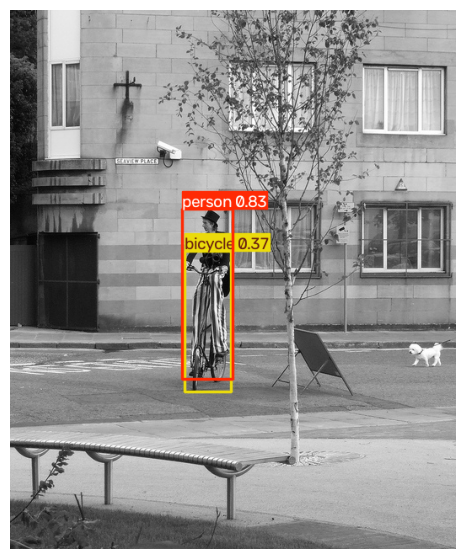

In [ ]:
# Visualize all YOLO detections for the missed-detection example.
annotated_image = result.plot()

plt.figure(figsize=(6, 7))
plt.imshow(annotated_image)
plt.axis('off')
plt.show()

A missing dog detection is treated as a missed detection rather than assigning a Box IoU of zero.

## 10.2 Successful-detection example

The second prototype sample is used to verify the complete localization evaluation pipeline.

In [ ]:
sample_annotation = experiment_annotations[1]

image_id_2 = sample_annotation['image_id']
image_2 = load_coco_image(image_id_2)
ground_truth_box_2 = coco_to_xyxy(sample_annotation['bbox'])

dog_detections_2 = detect_dogs(image_2)
best_detection_2 = select_best_detection(
    dog_detections_2,
    ground_truth_box_2
)

print('Image ID:', image_id_2)
print('Ground-truth box:', ground_truth_box_2)
print('Number of dog detections:', len(dog_detections_2))

Image ID: 61471
Ground-truth box: [272.1, 200.23, 424.07, 480.0]
Number of dog detections: 1


In [ ]:
if best_detection_2 is not None:
    predicted_box_2 = best_detection_2['box']
    confidence_2 = best_detection_2['confidence']
    box_iou_2 = calculate_iou(ground_truth_box_2, predicted_box_2)

    print('Predicted box:', predicted_box_2)
    print('Confidence:', confidence_2)
    print('Box IoU:', box_iou_2)
else:
    predicted_box_2 = None
    box_iou_2 = None
    print('No dog detection was found.')

Predicted box: [270.3365478515625, 199.290771484375, 425.139404296875, 479.680908203125]
Confidence: 0.9215543866157532
Box IoU: 0.9773199462668454


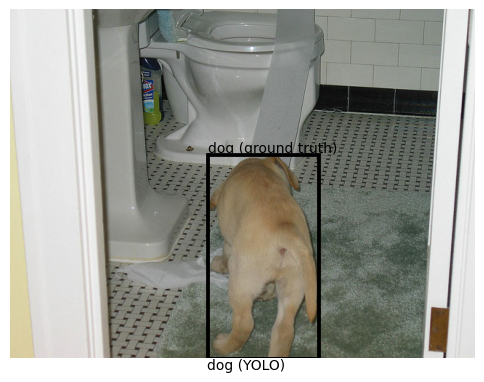

In [ ]:
# Visualize the ground-truth box for the successful-detection example.
fig, ax = plt.subplots(figsize=(6, 7))
ax.imshow(image_2)

x1, y1, x2, y2 = ground_truth_box_2

ground_truth_rect = Rectangle(
    (x1, y1),
    x2 - x1,
    y2 - y1,
    fill=False,
    linewidth=2
)

ax.add_patch(ground_truth_rect)
ax.text(
    x1,
    y1,
    'dog (ground truth)',
    fontsize=10,
    verticalalignment='bottom'
)

if predicted_box_2 is not None:
    px1, py1, px2, py2 = predicted_box_2

    predicted_rect = Rectangle(
        (px1, py1),
        px2 - px1,
        py2 - py1,
        fill=False,
        linewidth=2
    )

    ax.add_patch(predicted_rect)
    ax.text(
        px1,
        py2,
        'dog (YOLO)',
        fontsize=10,
        verticalalignment='top'
    )

ax.axis('off')
plt.show()